In [118]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

from isca_tools.utils.moist_physics import sphum_sat

In [78]:
path = '/Users/joshduffield/Documents/StAndrews/Isca/jobs/era5/surface_flux/av_annual_cycle/output/*.nc'

In [79]:
ds = xr.open_mfdataset(path)

In [145]:
ds_use = ds.sel(latitude=50, longitude=360-30, method='nearest').load()
ds_use['w_atm'] = np.sqrt(ds_use.u**2 + ds_use.v**2)
ds_use['rh_atm'] = ds_use.q / sphum_sat(ds_use.t, ds_use.sp)
ds_use['t_dq'] = ds_use.skt - ds_use.t
ds_use['net_up_flux'] = -ds_use.mslhf - ds_use.msshf - ds_use.msnlwrf

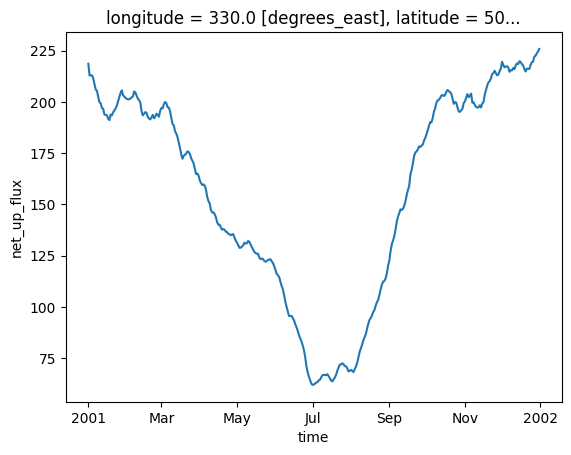

In [146]:
ds_use.net_up_flux.plot()

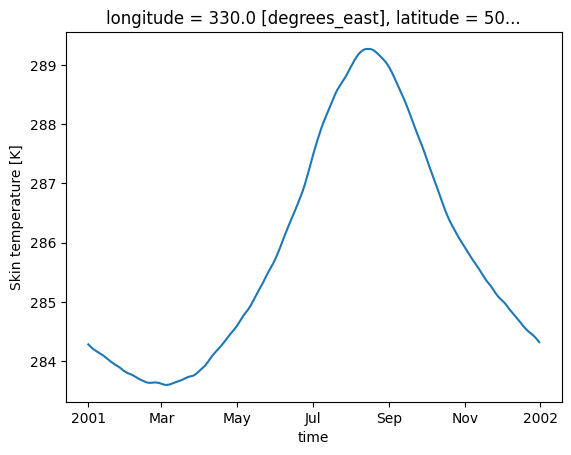

In [147]:
ds_use.skt.plot()
# ds_use.msshf.plot()

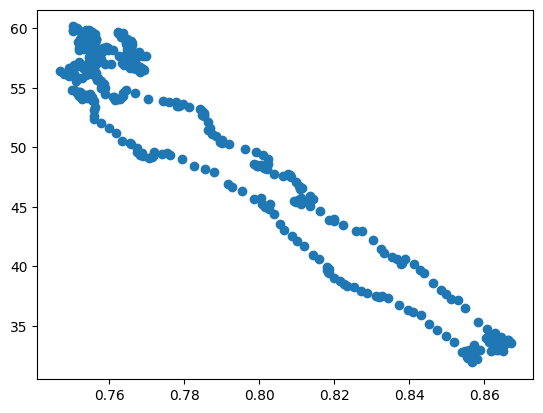

In [148]:
plt.scatter(ds_use.rh_atm, -ds_use.msnlwrf)

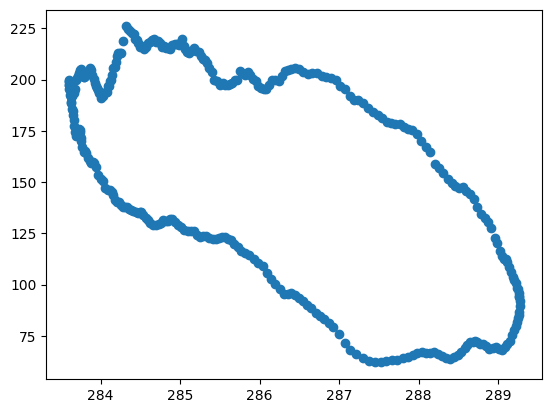

In [149]:
plt.scatter(ds_use.skt, ds_use.net_up_flux)

In [150]:
ds.sel(latitude=50, longitude=360-30, method='nearest').plot()
ds.sel(latitude=0, longitude=300, method='nearest').plot()

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)